# Forward-Forward Algorithm on MNIST (Unsupervised Masking)

This notebook implements a version of Geoffrey HInton's Forward-Forward (FF) algorithm using PyTorch.

## Acknowledgements
The structural foundation and initial inspiration for this implementation are derived from the [official PyTorch FF MNIST example](https://github.com/pytorch/examples/tree/main/mnist_forward_forward). That example is a modified implementation by Vivek V Patel, which was built upon the original Forward-Forward implementation by Mohammad Pezeshki.

In [82]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

In [83]:
dims = [784, 2000, 2000, 2000, 2000]

ff_lr = .05
threshold = 2
numBlurs = 3 
ff_epochs = 60

probe_lr = .05
probe_epochs = 10

batch_size = 512
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [84]:
#Normalize training data for zero centering.

def flatten_image(x):
    return torch.flatten(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)), 
    #transforms.Lambda(flatten_image)
])

train_loader = DataLoader(
    MNIST("./data/", train=True, download=True, transform=transform),
    batch_size, 
    shuffle = True,
    pin_memory=(device.type == 'cuda'),
    num_workers=4
    )

test_loader = DataLoader(
    MNIST("./data/", train=False, download=True, transform=transform),
    batch_size,
    pin_memory=(device.type == 'cuda'),
    num_workers=4
    )


In [85]:
#Blur kernel. [1/4 1/2, 1/4]'.*[1/4 1/2, 1/4]
kernel = torch.tensor([
    [0.0625, 0.1250, 0.0625],
    [0.1250, 0.2500, 0.1250],
    [0.0625, 0.1250, 0.0625]
],).view(1, 1, 3, 3)

kernel = kernel.to(device)

#Expects a flattened image.
def generate_negative_data(images, blurAmount=3):
    
    B, C = images.shape
    
    #Create random bit images
    bitmap = torch.randint(0 ,2 , (B, 1, 28, 28), dtype=torch.float32, device=images.device)

    #Blur bit image with filter (kernel) 
    with torch.no_grad():
        for _ in range(blurAmount):
            bitmap = F.conv2d(bitmap, kernel, padding=1)

    bitmap = (bitmap > 0.5).float()
    
    mask = bitmap.view(B, -1)

    shuffle_indices = torch.randperm(B, device=images.device)
    shuffled_images = images[shuffle_indices]
    
    negative_images = (images * mask) + (shuffled_images * (1.0 - mask))
    
    return negative_images

In [86]:
class FF_Layer(nn.Linear):
    def __init__(self, in_features, out_features, bias=True, device=None, dtype=None, 
                 lr=0.03, threshold=2.0):

        super().__init__(in_features, out_features, bias, device=device, dtype=dtype)
        self.relu = nn.ReLU()
        self.opt = torch.optim.Adam(self.parameters(), lr=lr)
        self.threshold = threshold
    
    def forward(self, x):
        #L2 norm
        x_direction = F.normalize(x, p=2, dim=1, eps=1e-4)
        return self.relu(F.linear(x_direction, self.weight, self.bias))
    
    def layer_train(self, x_pos, x_neg):
        self.opt.zero_grad()

        out_pos = self.forward(x_pos)
        out_neg = self.forward(x_neg)

        goodness_pos = out_pos.pow(2).mean(1)
        goodness_neg = out_neg.pow(2).mean(1)

        loss_pos = F.softplus(-goodness_pos + self.threshold).mean()
        loss_neg = F.softplus(goodness_neg - self.threshold).mean()
            
        loss = loss_pos + loss_neg
        loss.backward()
        self.opt.step()

        return out_pos.detach(), out_neg.detach(), goodness_pos.mean().item(), goodness_neg.mean().item()

In [87]:
class Network(nn.Module):
    def __init__(self, dims, lr=0.03, threshold=2.0, device=None):
        super().__init__()
        self.ff_layers = nn.ModuleList()
        for i in range(len(dims) - 1):
            layer = FF_Layer(
                in_features=dims[i],
                out_features=dims[i + 1],
                lr=lr,
                threshold=threshold,
                device=device
            )
            self.ff_layers.append(layer)
    
    def ff_train(self, x_pos, x_neg):
        h_pos, h_neg = x_pos, x_neg
        batch_g_pos = []
        batch_g_neg = []

        for layer in self.ff_layers:
            h_pos, h_neg, g_pos, g_neg = layer.layer_train(h_pos, h_neg)
            batch_g_pos.append(g_pos)
            batch_g_neg.append(g_neg)
            
        return batch_g_pos, batch_g_neg


    def extract_features(self, x):
            features = []
            with torch.no_grad():
                h = x
                for i, layer in enumerate(self.ff_layers):
                    h = layer(h)
                    if i > 0:
                        features.append(h)
                        
            return torch.cat(features, dim=1)


In [88]:
class LinearProbe(nn.Module):
    def __init__(self, in_features, num_classes=10, lr=0.01, device=None):
        super().__init__()
        self.layer = nn.Linear(in_features, num_classes, device=device)
        self.opt = torch.optim.Adam(self.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss()

    def train_probe(self, features, labels):
        self.opt.zero_grad()
            
        logits = self.layer(features)
        loss = self.criterion(logits, labels)
            
        loss.backward()
        self.opt.step()

    def predict(self, features):
        self.eval()

        with torch.no_grad():
            logits = self.layer(features)
            predictions = torch.argmax(logits, dim=1)
            
        return predictions

In [89]:
from tqdm.auto import tqdm
feature_extractor = Network(dims = dims, lr = ff_lr, threshold = threshold, device=device)
feature_extractor = torch.compile(feature_extractor)

num_layers = len(dims) - 1
history = {
    'pos': {i: [] for i in range(num_layers)},
    'neg': {i: [] for i in range(num_layers)}
}

probe_in_features = sum(dims[2:])
classifier = LinearProbe(in_features=probe_in_features, num_classes=10, lr = probe_lr, device=device)

for ff_epoch in range(ff_epochs):
    ff_loop = tqdm(train_loader, desc=f"FF Epoch [{ff_epoch+1}/{ff_epochs}]", leave=True)

    epoch_g_pos = [0.0] * num_layers
    epoch_g_neg = [0.0] * num_layers
    batches = 0

    for pos_images, _ in ff_loop:
        pos_images = pos_images.to(device)
        pos_images = pos_images.view(pos_images.size(0), -1)
        
        neg_images = generate_negative_data(pos_images, numBlurs)

        batch_g_pos, batch_g_neg = feature_extractor.ff_train(pos_images, neg_images)

        for i in range(num_layers):
            epoch_g_pos[i] += batch_g_pos[i]
            epoch_g_neg[i] += batch_g_neg[i]
        batches += 1

    for i in range(num_layers):
        history['pos'][i].append(epoch_g_pos[i] / batches)
        history['neg'][i].append(epoch_g_neg[i] / batches)

for probe_epoch in range(probe_epochs):
    probe_loop = tqdm(train_loader, desc=f"Probe Epoch [{probe_epoch+1}/{probe_epochs}]", leave=True)
    for images, labels in probe_loop:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)
        
        with torch.no_grad():
            features = feature_extractor.extract_features(images)
            
        classifier.train_probe(features, labels)


Probe Epoch [10/10]: 100%|██████████| 118/118 [00:02<00:00, 40.25it/s]


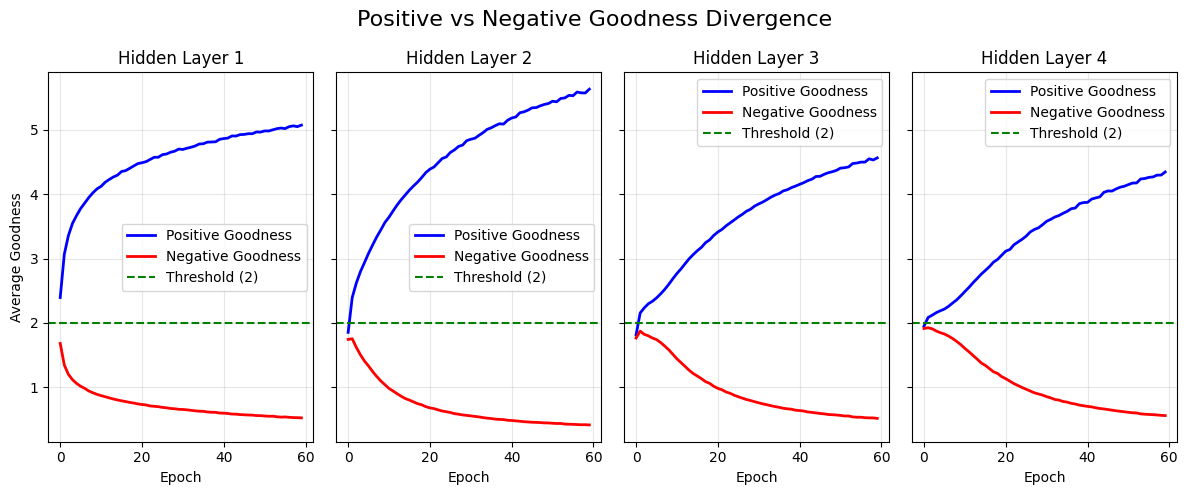

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, num_layers, figsize=(12, 5), sharey=True)
if num_layers == 1: axes = [axes]

fig.suptitle("Positive vs Negative Goodness Divergence", fontsize=16)

for i, ax in enumerate(axes):
    ax.plot(history['pos'][i], label='Positive Goodness', color='blue', linewidth=2)
    ax.plot(history['neg'][i], label='Negative Goodness', color='red', linewidth=2)
    
    ax.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    
    ax.set_title(f"Hidden Layer {i+1}")
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Average Goodness")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9694    0.9704    0.9699       980
           1     0.9928    0.9762    0.9845      1135
           2     0.9174    0.9574    0.9369      1032
           3     0.8412    0.8287    0.8349      1010
           4     0.8867    0.9725    0.9276       982
           5     0.9030    0.8139    0.8561       892
           6     0.9072    0.9791    0.9418       958
           7     0.9702    0.8230    0.8905      1028
           8     0.8385    0.9220    0.8782       974
           9     0.9239    0.8910    0.9072      1009

    accuracy                         0.9146     10000
   macro avg     0.9150    0.9134    0.9128     10000
weighted avg     0.9165    0.9146    0.9141     10000



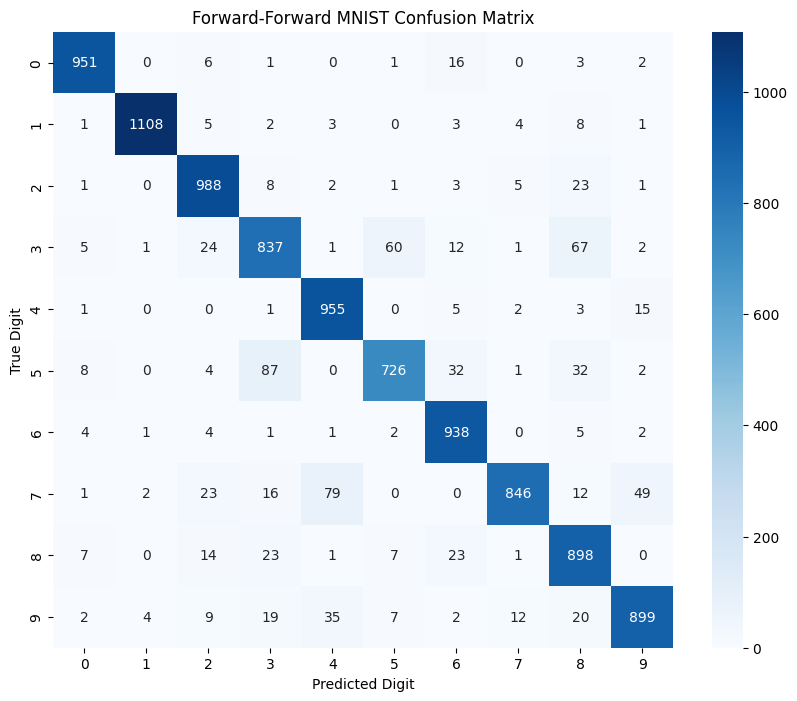

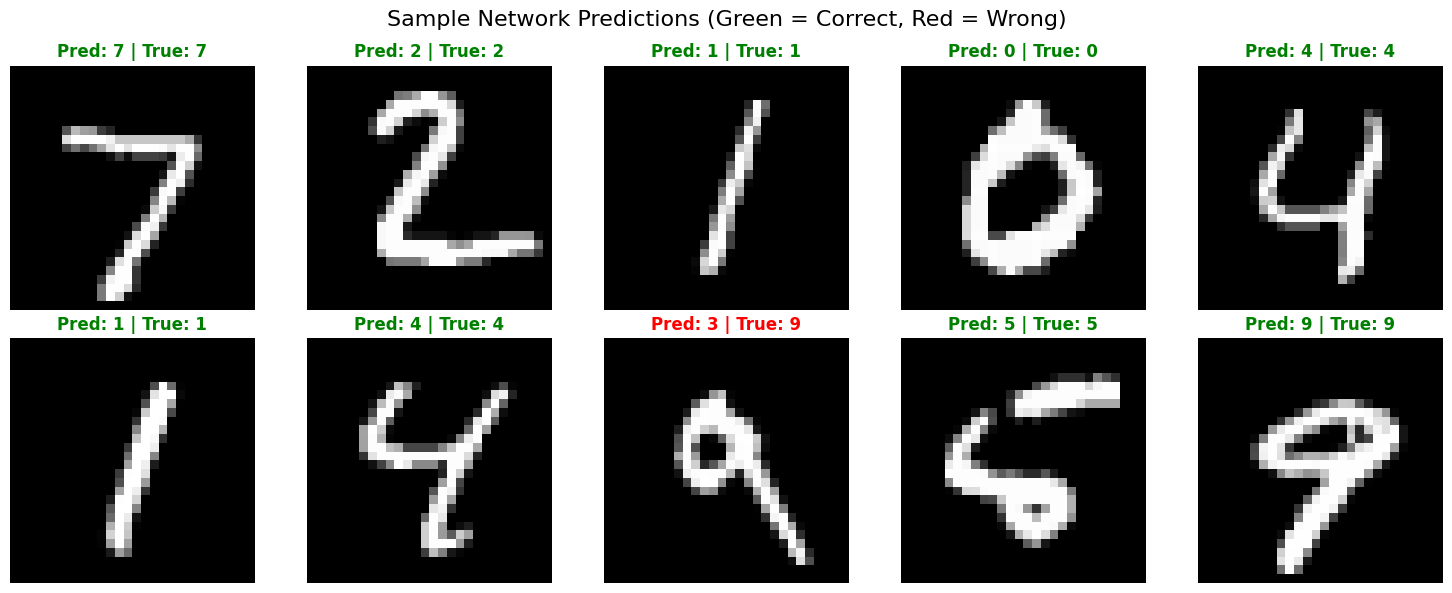

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_trues = []

sample_images = None
sample_preds = None
sample_trues = None

for test_images, test_labels in test_loader:
    test_images = test_images.to(device)
    test_images = test_images.view(test_images.size(0), -1)
    
    with torch.no_grad():
        test_features = feature_extractor.extract_features(test_images)
        predicted_labels = classifier.predict(test_features)

    all_preds.extend(predicted_labels.cpu().numpy())
    all_trues.extend(test_labels.cpu().numpy())
    
    if sample_images is None:
        sample_images = test_images.cpu().numpy()[:10]
        sample_preds = predicted_labels.cpu().numpy()[:10]
        sample_trues = test_labels.cpu().numpy()[:10]

print("\n--- Classification Report ---")
print(classification_report(all_trues, all_preds, digits=4))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_trues, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('Forward-Forward MNIST Confusion Matrix')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Network Predictions (Green = Correct, Red = Wrong)', fontsize=16)

for i, ax in enumerate(axes.flat):
    img = sample_images[i].reshape(28, 28)
    
    ax.imshow(img, cmap='gray')
    
    color = 'green' if sample_preds[i] == sample_trues[i] else 'red'
    ax.set_title(f"Pred: {sample_preds[i]} | True: {sample_trues[i]}", color=color, fontweight='bold')
    ax.axis('off')
    
plt.tight_layout()
plt.show()